# CWRU bearing fault classification
## 1D CNN · kernels 100 and 50

A notebook version of `1D_CNN_v2_100-50_CWRU_split.py`, with all ten supplied CWRU files included.
The source code stays in its original order. The complete outer run loop stays in one code cell.
The only executable changes are portable data/output paths and the setup cell that creates the output directories.

**Run:** install `requirements.txt`, open this notebook from the `cwru_cnn` folder, then restart the kernel and run all cells from top to bottom.
The original default is **10 runs**, with up to **1,000 epochs per run** and early stopping. CUDA is used when available; otherwise the code uses the CPU.

No training outputs are embedded in this distribution. Running the notebook generates fresh results.

### Workflow

1. Imports and timing
2. Output folders
3. Run settings and result lists
4. Original per-run workflow: loading → preprocessing → block split → normalization → CNN → training → evaluation
5. Original averages and confusion matrix

## 1. Imports and timing

All imports and the original `if __name__ == "__main__"` guard are retained. Jupyter runs these cells as `__main__`.

In [ ]:
if __name__ == "__main__": # packets
    import time
    t0 = time.perf_counter()
    # =========================
    # Standard Library
    # =========================
    import os
    import copy
    # =========================
    # Numerical & Data Handling
    # =========================
    import numpy as np
    import pandas as pd
    import scipy.io as scio
    # =========================
    # Signal Processing
    # =========================
    from scipy import signal, ndimage
    # =========================
    # Machine Learning (Sklearn)
    # =========================
    from sklearn.metrics import classification_report, confusion_matrix
    # =========================
    # Deep Learning
    # =========================
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    # =========================
    # Visualization
    # =========================
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.manifold import TSNE


# print("CPU:", True)
# print("CUDA:", torch.cuda.is_available())
# print("XPU:", hasattr(torch, "xpu") and torch.xpu.is_available())
# print("MPS:", hasattr(torch.backends, "mps") and torch.backends.mps.is_available())



## 2. Output folders

This small setup cell creates the directories used by the original model and figure saving calls.
All data and output paths are relative to this notebook's folder.

In [18]:
os.makedirs(os.path.join('outputs', 'models'), exist_ok=True)
os.makedirs(os.path.join('outputs', 'figures'), exist_ok=True)


## 3. Run settings and result lists

The original `n_runs = 10` and result accumulators are retained. Run this cell again before starting a fresh set of runs.

In [19]:
n_runs = 10

cms = []
cms_percent = []
accs = []
epochs = []




## 4. Original per-run workflow

The complete `for runs in range(n_runs)` loop below is retained, including all function and class definitions, comments, training, and per-run evaluation.
The existing comment headings identify each stage inside the cell.

### Included classes

Each file has its own class directory under `data/CWRU/`. Class labels are the directory names, sorted alphabetically by the original loader.

| Label | Class directory | Included file |
| ---: | --- | --- |
| 0 | `Ball_007` | `Ball_007.mat` |
| 1 | `Ball_014` | `Ball_014.mat` |
| 2 | `Ball_021` | `Ball_021.mat` |
| 3 | `Healthy` | `Healthy.mat` |
| 4 | `InnerR_007` | `InnerR_007.mat` |
| 5 | `InnerR_014` | `InnerR_014.mat` |
| 6 | `InnerR_021` | `InnerR_021.mat` |
| 7 | `OuterR_007` | `OuterR_007.mat` |
| 8 | `OuterR_014` | `OuterR_014.mat` |
| 9 | `OuterR_021` | `OuterR_021.mat` |

### Original settings

| Setting | Value |
| --- | --- |
| Block size | 10,000 samples |
| Window size / stride | 5,000 / 2,500 samples |
| Requested train / validation / test ratios | 0.45 / 0.10 / 0.45 |
| Split seed | `None` |
| Batch size | 32 |
| Optimizer / learning rate | Adam / `1e-5` |
| Loss | Cross entropy |
| Dropout | 0.3 |
| Maximum epochs / patience | 1,000 / 20 |

Ratios are applied to whole blocks and rounded by the original `split_counts` function.
Training/validation curves keep the original condition `400 < epoc_hist[-1] < 1000`; the commented per-run confusion matrix and t-SNE code remain commented.

Classes: ['Ball_007', 'Ball_014', 'Ball_021', 'Healthy', 'InnerR_007', 'InnerR_014', 'InnerR_021', 'OuterR_007', 'OuterR_014', 'OuterR_021']
Shared usable length: 120000

Final dataset shapes:
Train: (150, 1, 5000) (150,)
Val:   (30, 1, 5000) (30,)
Test:  (180, 1, 5000) (180,)
Using device: cuda
Run 1
Total runtime: 0.1291 seconds
Early stopping triggered
Test Loss: 0.0446
Test Acc:  0.9833

Classification Report:
              precision    recall  f1-score   support

    Ball_007       0.95      1.00      0.97        18
    Ball_014       1.00      1.00      1.00        18
    Ball_021       1.00      0.94      0.97        18
     Healthy       1.00      1.00      1.00        18
  InnerR_007       1.00      1.00      1.00        18
  InnerR_014       0.90      1.00      0.95        18
  InnerR_021       1.00      1.00      1.00        18
  OuterR_007       1.00      1.00      1.00        18
  OuterR_014       1.00      1.00      1.00        18
  OuterR_021       1.00      0.89      0.

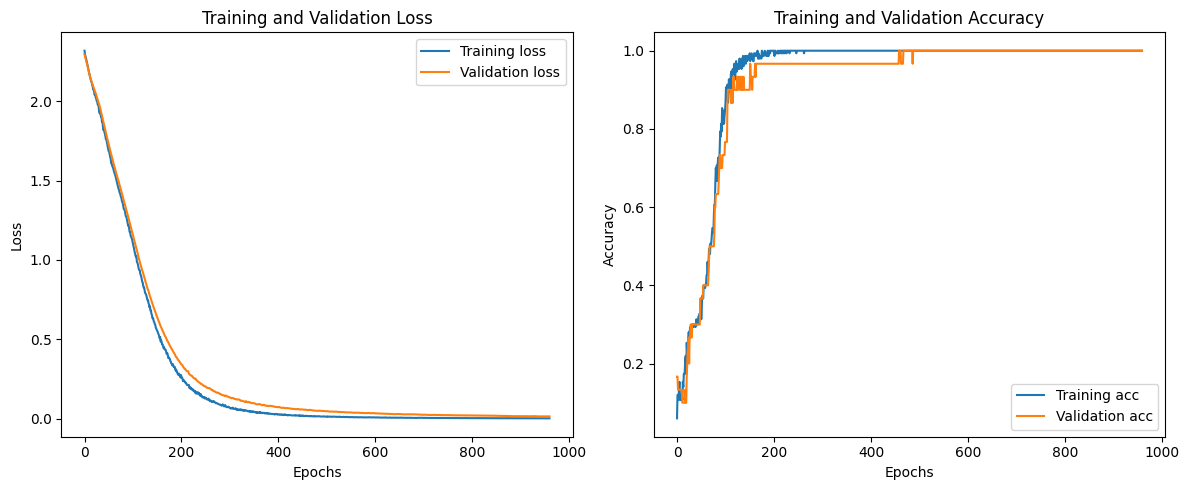

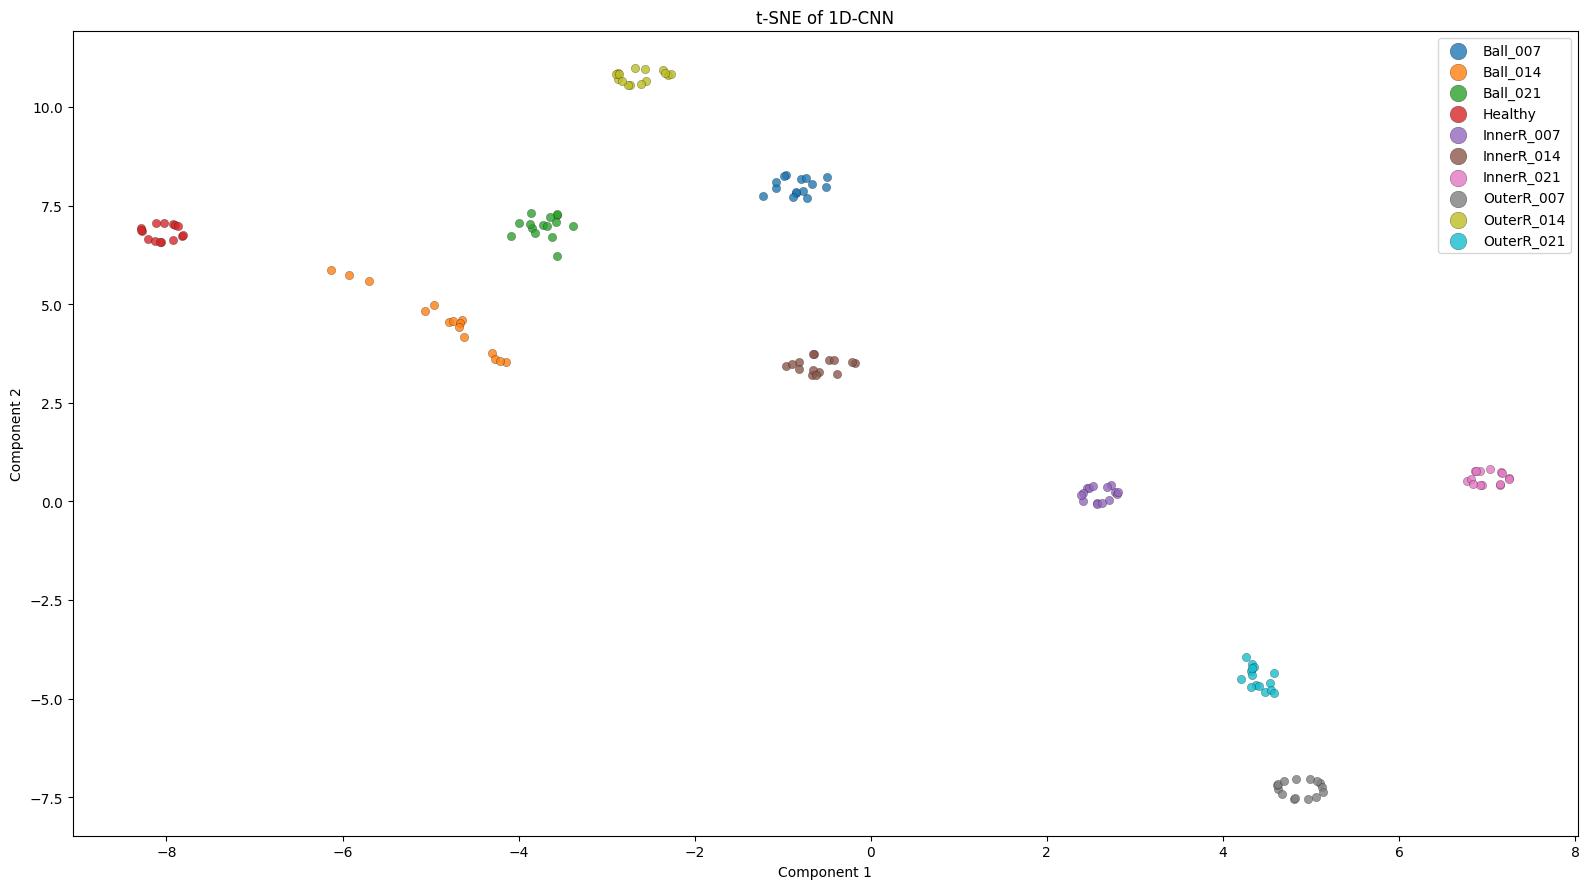

Classes: ['Ball_007', 'Ball_014', 'Ball_021', 'Healthy', 'InnerR_007', 'InnerR_014', 'InnerR_021', 'OuterR_007', 'OuterR_014', 'OuterR_021']
Shared usable length: 120000

Final dataset shapes:
Train: (150, 1, 5000) (150,)
Val:   (30, 1, 5000) (30,)
Test:  (180, 1, 5000) (180,)
Using device: cuda
Run 2
Total runtime: 27.0253 seconds
Test Loss: 0.0171
Test Acc:  0.9944

Classification Report:
              precision    recall  f1-score   support

    Ball_007       1.00      1.00      1.00        18
    Ball_014       1.00      1.00      1.00        18
    Ball_021       1.00      1.00      1.00        18
     Healthy       1.00      1.00      1.00        18
  InnerR_007       1.00      1.00      1.00        18
  InnerR_014       0.95      1.00      0.97        18
  InnerR_021       1.00      1.00      1.00        18
  OuterR_007       1.00      1.00      1.00        18
  OuterR_014       1.00      1.00      1.00        18
  OuterR_021       1.00      0.94      0.97        18

    accura

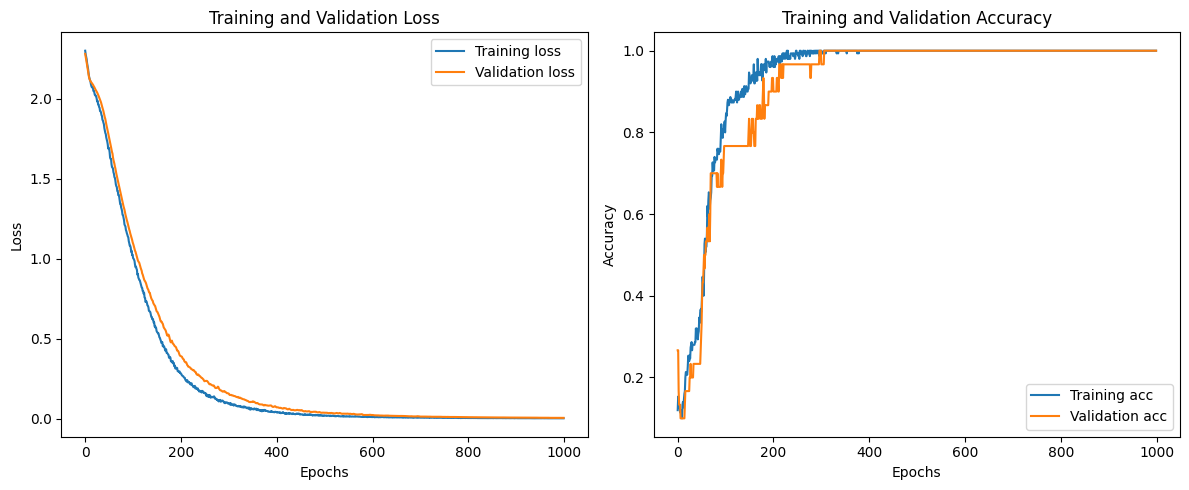

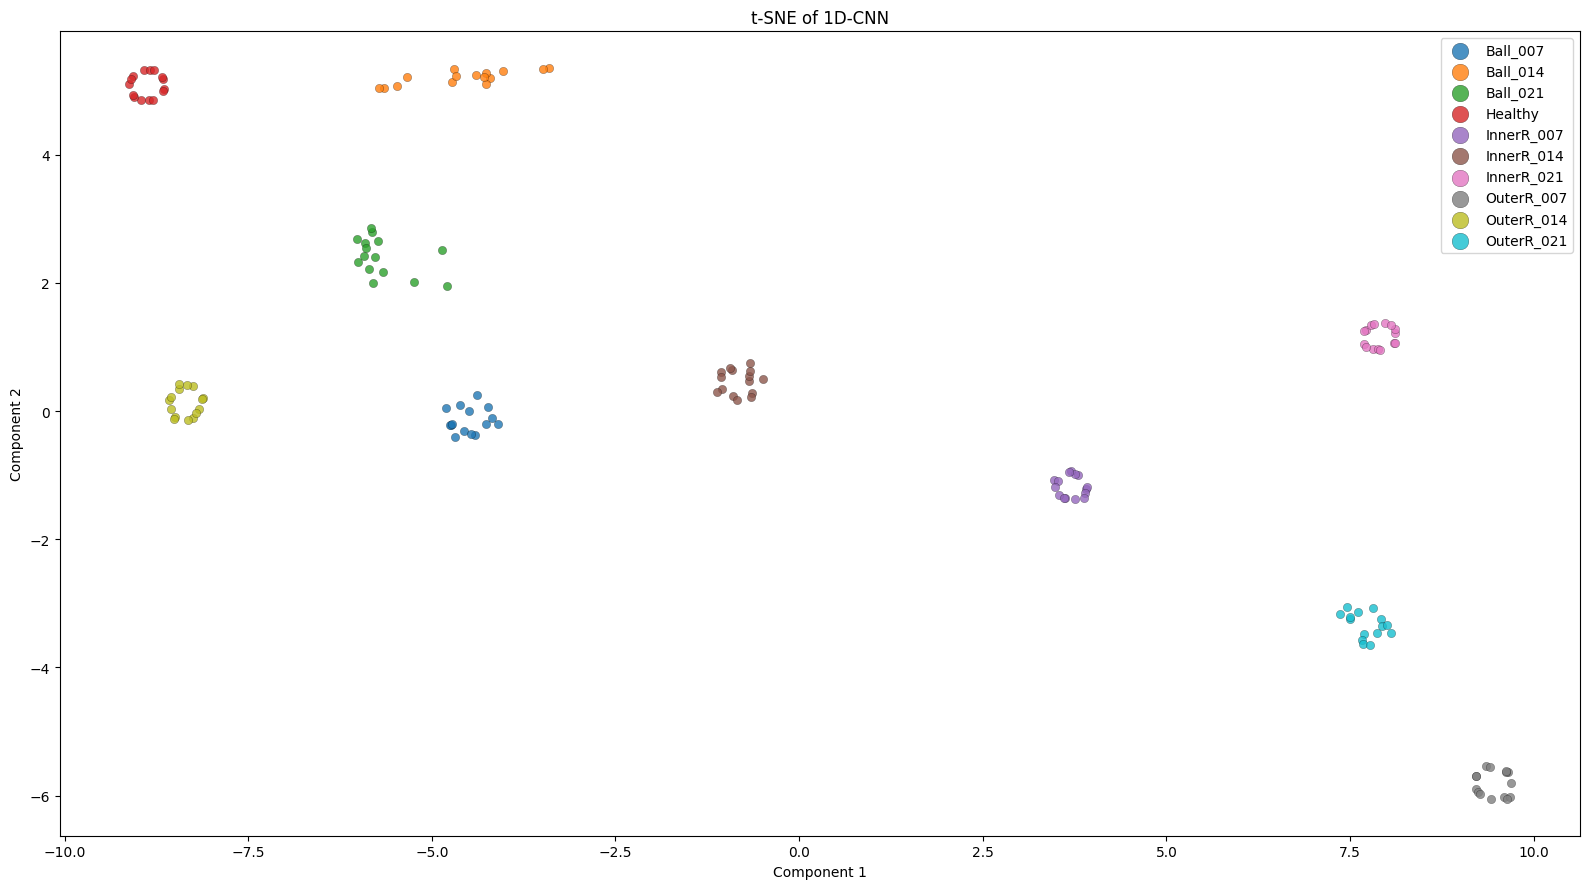

Classes: ['Ball_007', 'Ball_014', 'Ball_021', 'Healthy', 'InnerR_007', 'InnerR_014', 'InnerR_021', 'OuterR_007', 'OuterR_014', 'OuterR_021']
Shared usable length: 120000

Final dataset shapes:
Train: (150, 1, 5000) (150,)
Val:   (30, 1, 5000) (30,)
Test:  (180, 1, 5000) (180,)
Using device: cuda
Run 3
Total runtime: 55.4106 seconds
Early stopping triggered
Test Loss: 0.0455
Test Acc:  0.9778

Classification Report:
              precision    recall  f1-score   support

    Ball_007       0.82      1.00      0.90        18
    Ball_014       1.00      1.00      1.00        18
    Ball_021       1.00      0.78      0.88        18
     Healthy       1.00      1.00      1.00        18
  InnerR_007       1.00      1.00      1.00        18
  InnerR_014       1.00      1.00      1.00        18
  InnerR_021       1.00      1.00      1.00        18
  OuterR_007       1.00      1.00      1.00        18
  OuterR_014       1.00      1.00      1.00        18
  OuterR_021       1.00      1.00      1

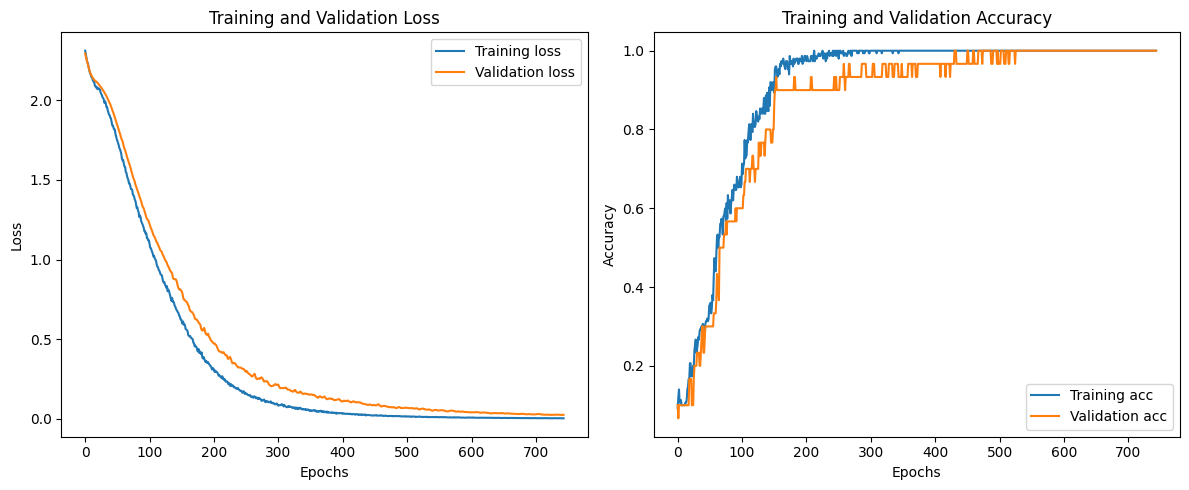

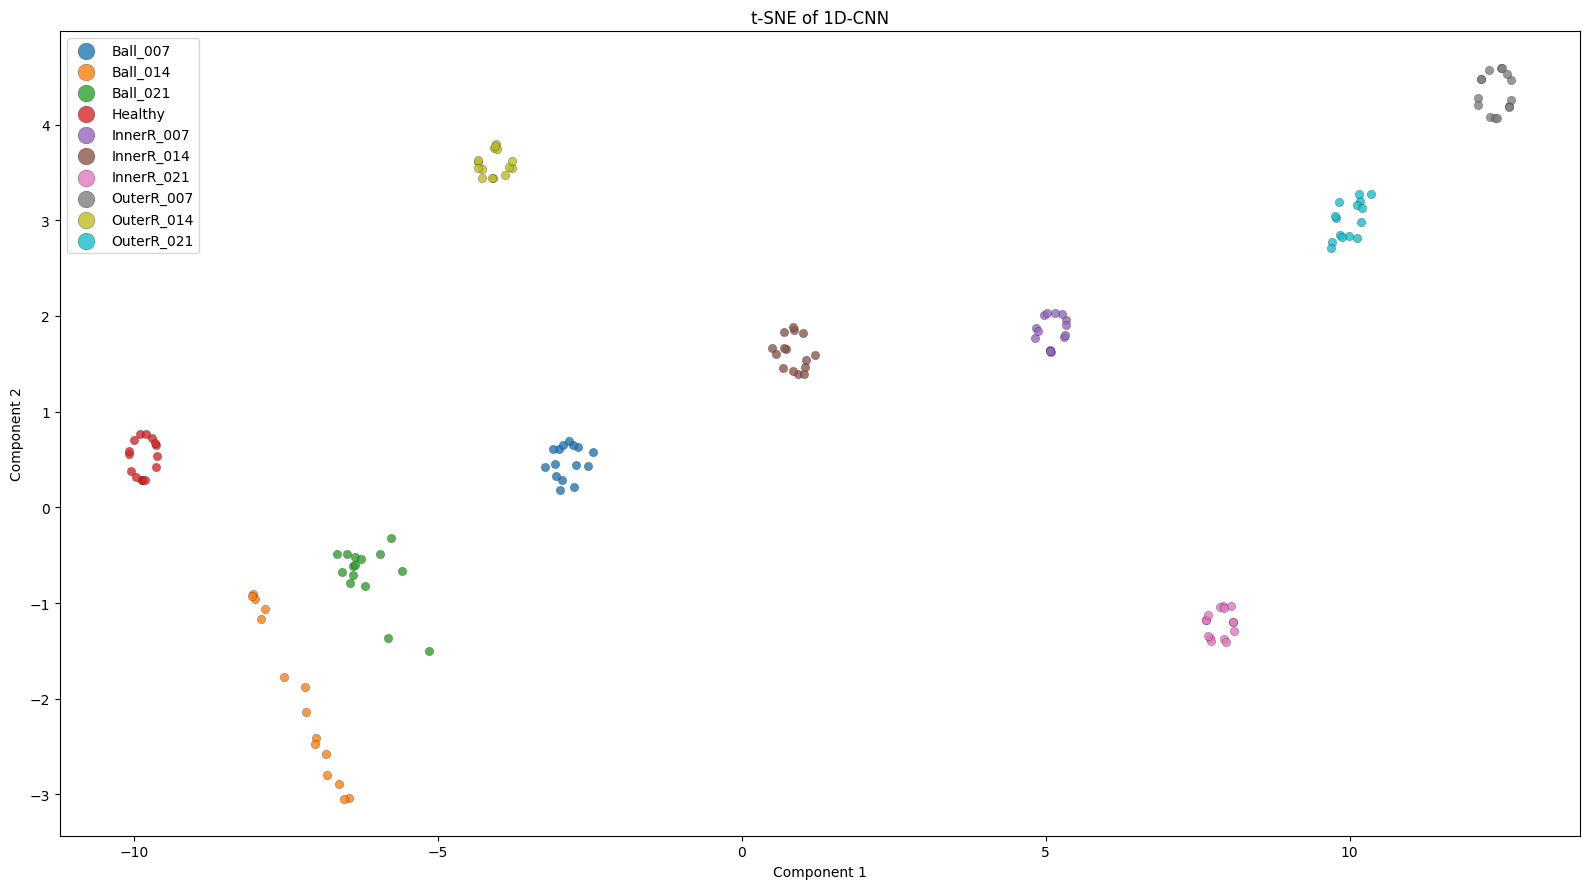

Classes: ['Ball_007', 'Ball_014', 'Ball_021', 'Healthy', 'InnerR_007', 'InnerR_014', 'InnerR_021', 'OuterR_007', 'OuterR_014', 'OuterR_021']
Shared usable length: 120000

Final dataset shapes:
Train: (150, 1, 5000) (150,)
Val:   (30, 1, 5000) (30,)
Test:  (180, 1, 5000) (180,)
Using device: cuda
Run 4
Total runtime: 75.6846 seconds
Early stopping triggered
Test Loss: 0.3003
Test Acc:  0.9111

Classification Report:
              precision    recall  f1-score   support

    Ball_007       0.75      1.00      0.86        18
    Ball_014       1.00      0.50      0.67        18
    Ball_021       0.62      0.72      0.67        18
     Healthy       1.00      1.00      1.00        18
  InnerR_007       1.00      1.00      1.00        18
  InnerR_014       0.94      0.94      0.94        18
  InnerR_021       1.00      1.00      1.00        18
  OuterR_007       1.00      1.00      1.00        18
  OuterR_014       1.00      1.00      1.00        18
  OuterR_021       0.94      0.94      0

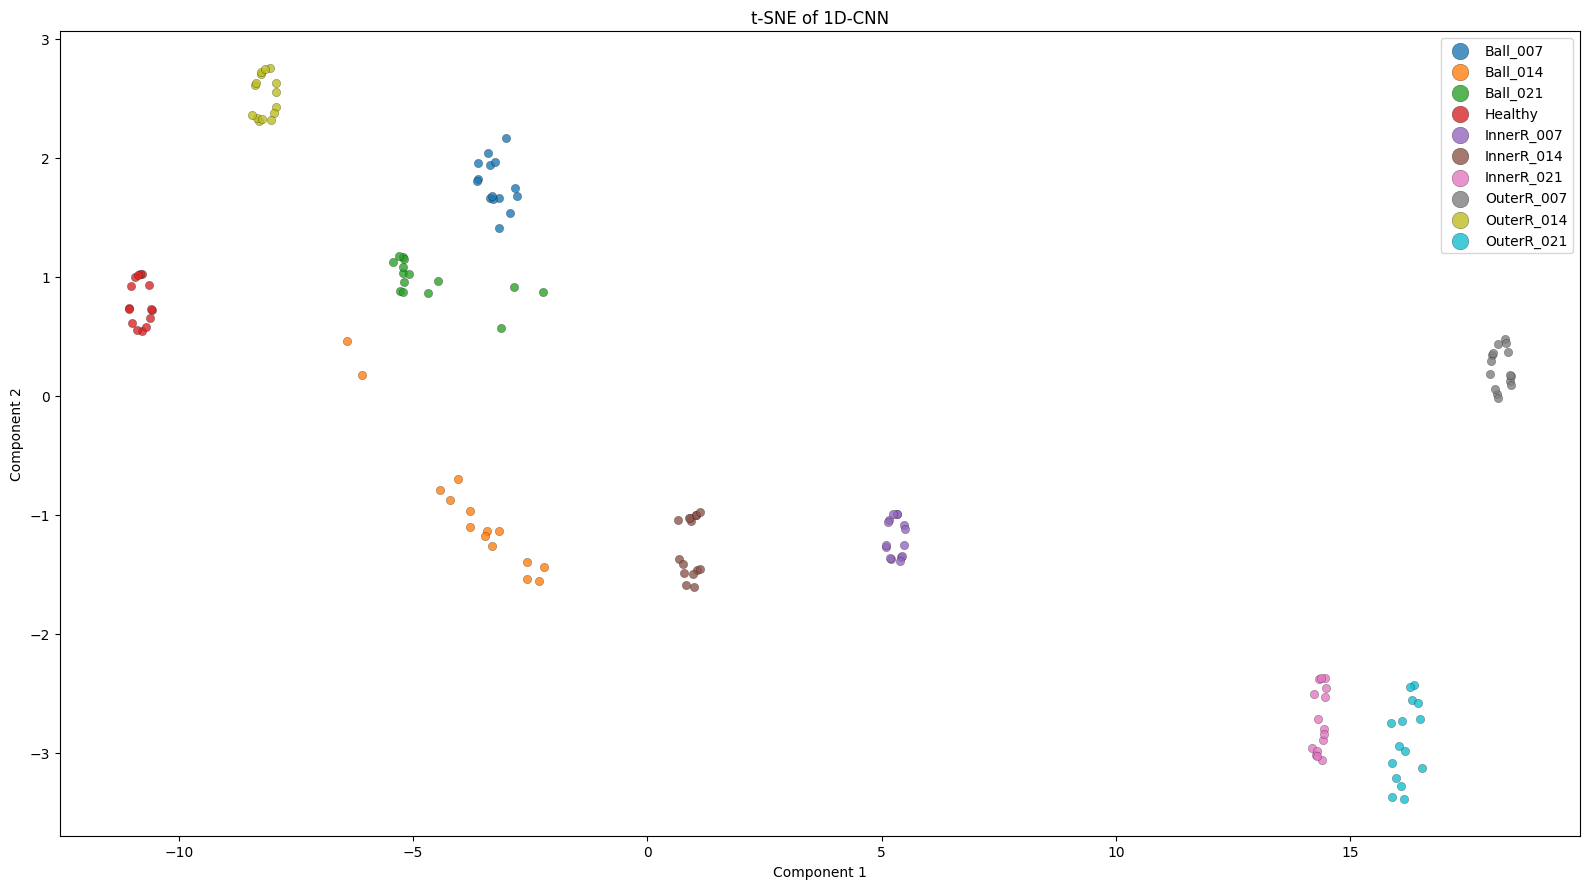

Classes: ['Ball_007', 'Ball_014', 'Ball_021', 'Healthy', 'InnerR_007', 'InnerR_014', 'InnerR_021', 'OuterR_007', 'OuterR_014', 'OuterR_021']
Shared usable length: 120000

Final dataset shapes:
Train: (150, 1, 5000) (150,)
Val:   (30, 1, 5000) (30,)
Test:  (180, 1, 5000) (180,)
Using device: cuda
Run 5
Total runtime: 83.7432 seconds
Early stopping triggered
Test Loss: 0.1119
Test Acc:  0.9722

Classification Report:
              precision    recall  f1-score   support

    Ball_007       0.95      1.00      0.97        18
    Ball_014       1.00      0.78      0.88        18
    Ball_021       0.81      0.94      0.87        18
     Healthy       1.00      1.00      1.00        18
  InnerR_007       1.00      1.00      1.00        18
  InnerR_014       1.00      1.00      1.00        18
  InnerR_021       1.00      1.00      1.00        18
  OuterR_007       1.00      1.00      1.00        18
  OuterR_014       1.00      1.00      1.00        18
  OuterR_021       1.00      1.00      1

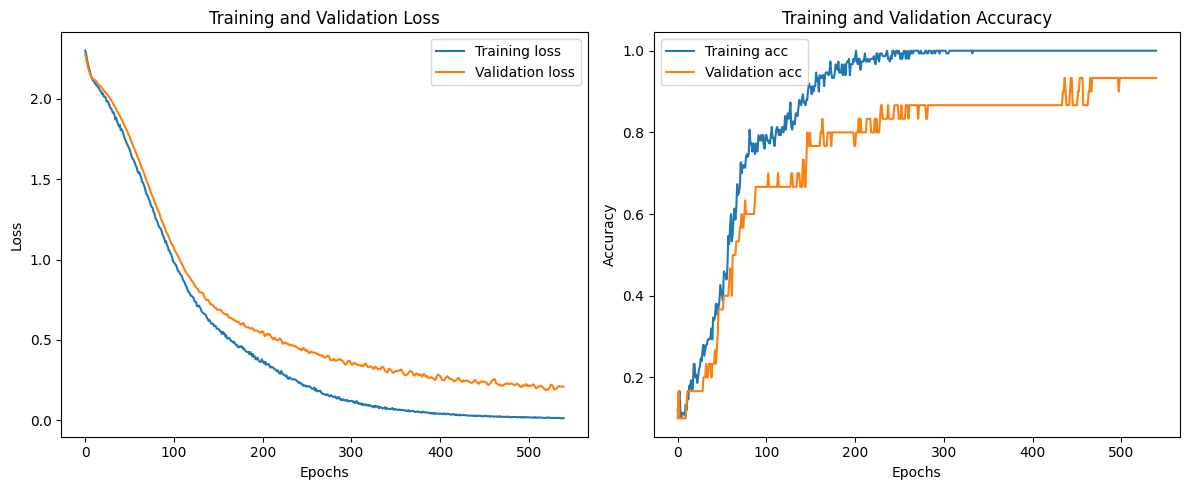

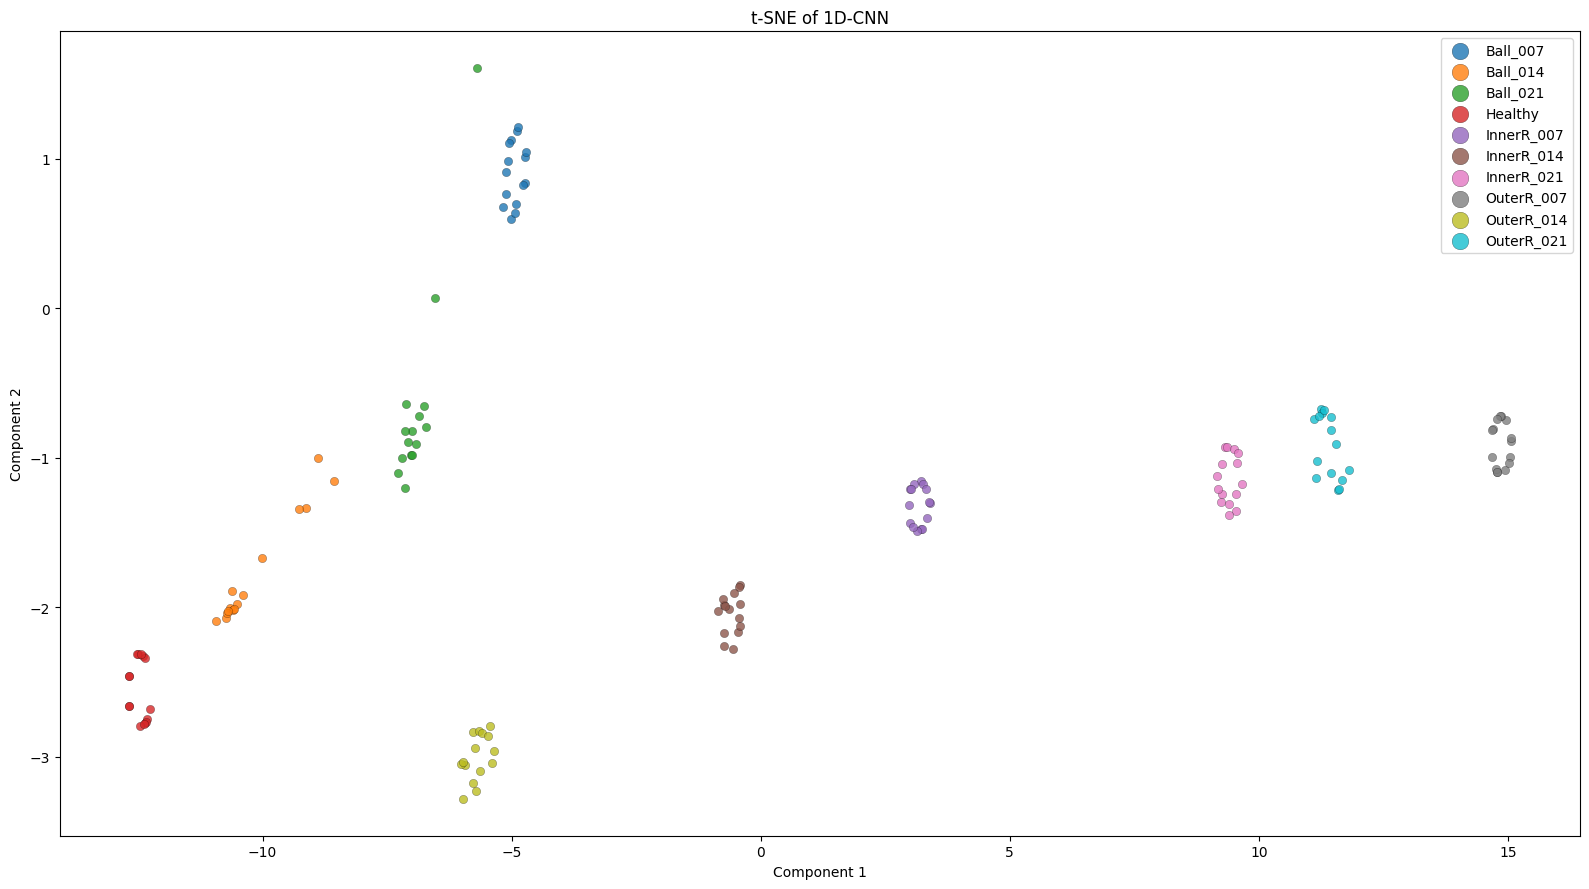

Classes: ['Ball_007', 'Ball_014', 'Ball_021', 'Healthy', 'InnerR_007', 'InnerR_014', 'InnerR_021', 'OuterR_007', 'OuterR_014', 'OuterR_021']
Shared usable length: 120000

Final dataset shapes:
Train: (150, 1, 5000) (150,)
Val:   (30, 1, 5000) (30,)
Test:  (180, 1, 5000) (180,)
Using device: cuda
Run 6
Total runtime: 100.3858 seconds
Early stopping triggered
Test Loss: 0.0491
Test Acc:  0.9889

Classification Report:
              precision    recall  f1-score   support

    Ball_007       1.00      1.00      1.00        18
    Ball_014       1.00      0.94      0.97        18
    Ball_021       0.95      1.00      0.97        18
     Healthy       1.00      1.00      1.00        18
  InnerR_007       1.00      1.00      1.00        18
  InnerR_014       0.95      1.00      0.97        18
  InnerR_021       1.00      1.00      1.00        18
  OuterR_007       1.00      1.00      1.00        18
  OuterR_014       1.00      1.00      1.00        18
  OuterR_021       1.00      0.94      

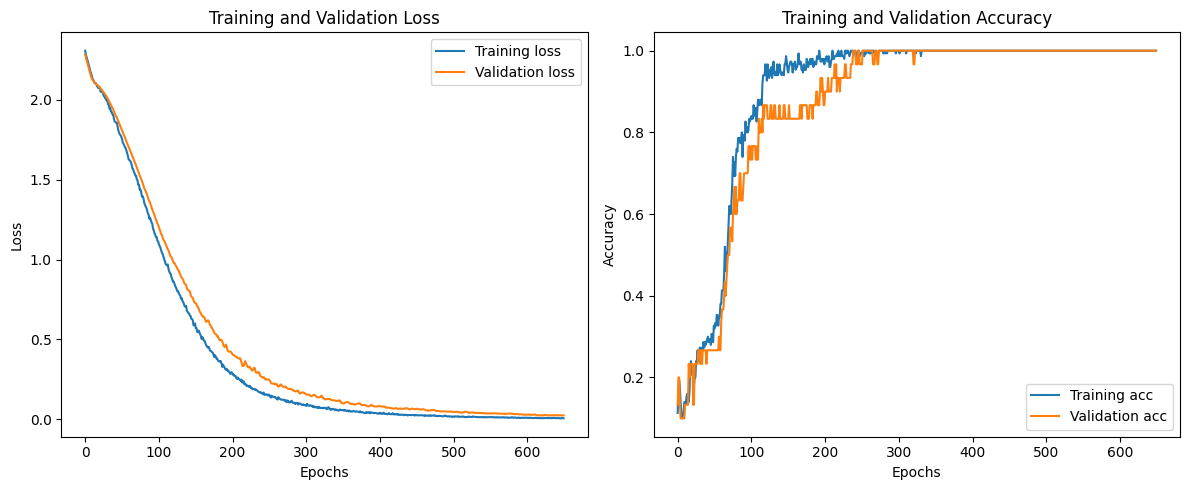

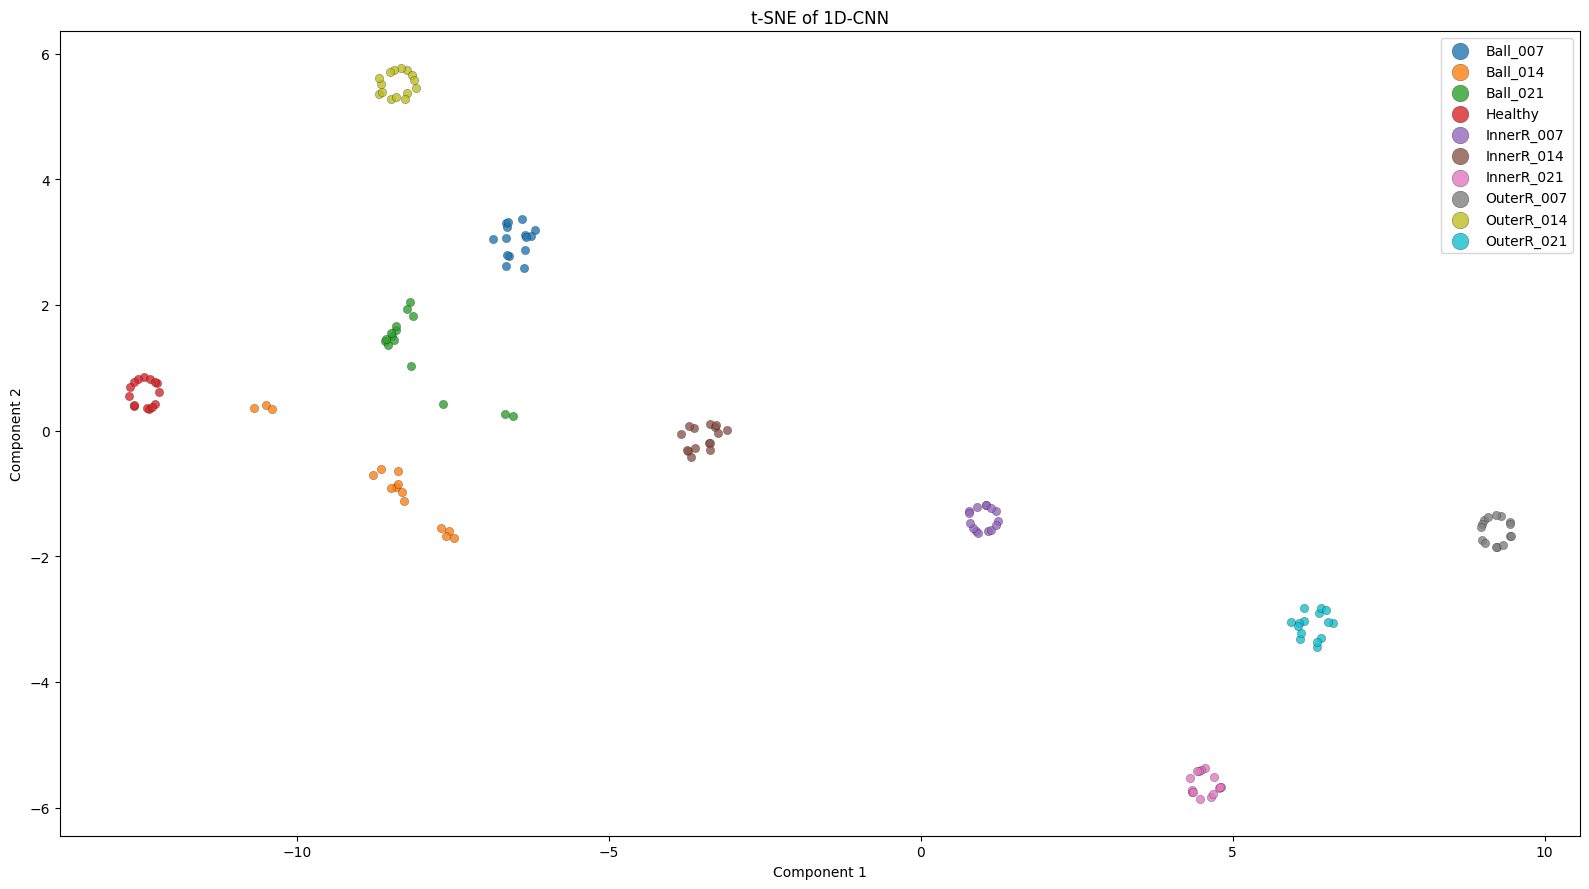

Classes: ['Ball_007', 'Ball_014', 'Ball_021', 'Healthy', 'InnerR_007', 'InnerR_014', 'InnerR_021', 'OuterR_007', 'OuterR_014', 'OuterR_021']
Shared usable length: 120000

Final dataset shapes:
Train: (150, 1, 5000) (150,)
Val:   (30, 1, 5000) (30,)
Test:  (180, 1, 5000) (180,)
Using device: cuda
Run 7
Total runtime: 118.1802 seconds
Early stopping triggered
Test Loss: 0.2052
Test Acc:  0.9556

Classification Report:
              precision    recall  f1-score   support

    Ball_007       1.00      1.00      1.00        18
    Ball_014       1.00      0.94      0.97        18
    Ball_021       0.95      1.00      0.97        18
     Healthy       1.00      1.00      1.00        18
  InnerR_007       1.00      1.00      1.00        18
  InnerR_014       0.72      1.00      0.84        18
  InnerR_021       1.00      1.00      1.00        18
  OuterR_007       1.00      1.00      1.00        18
  OuterR_014       1.00      1.00      1.00        18
  OuterR_021       1.00      0.61      

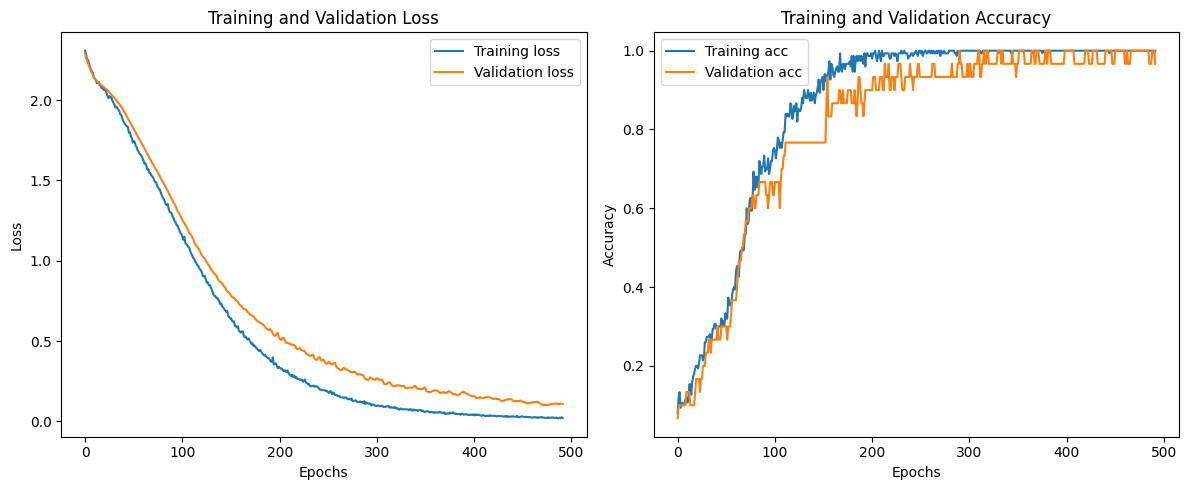

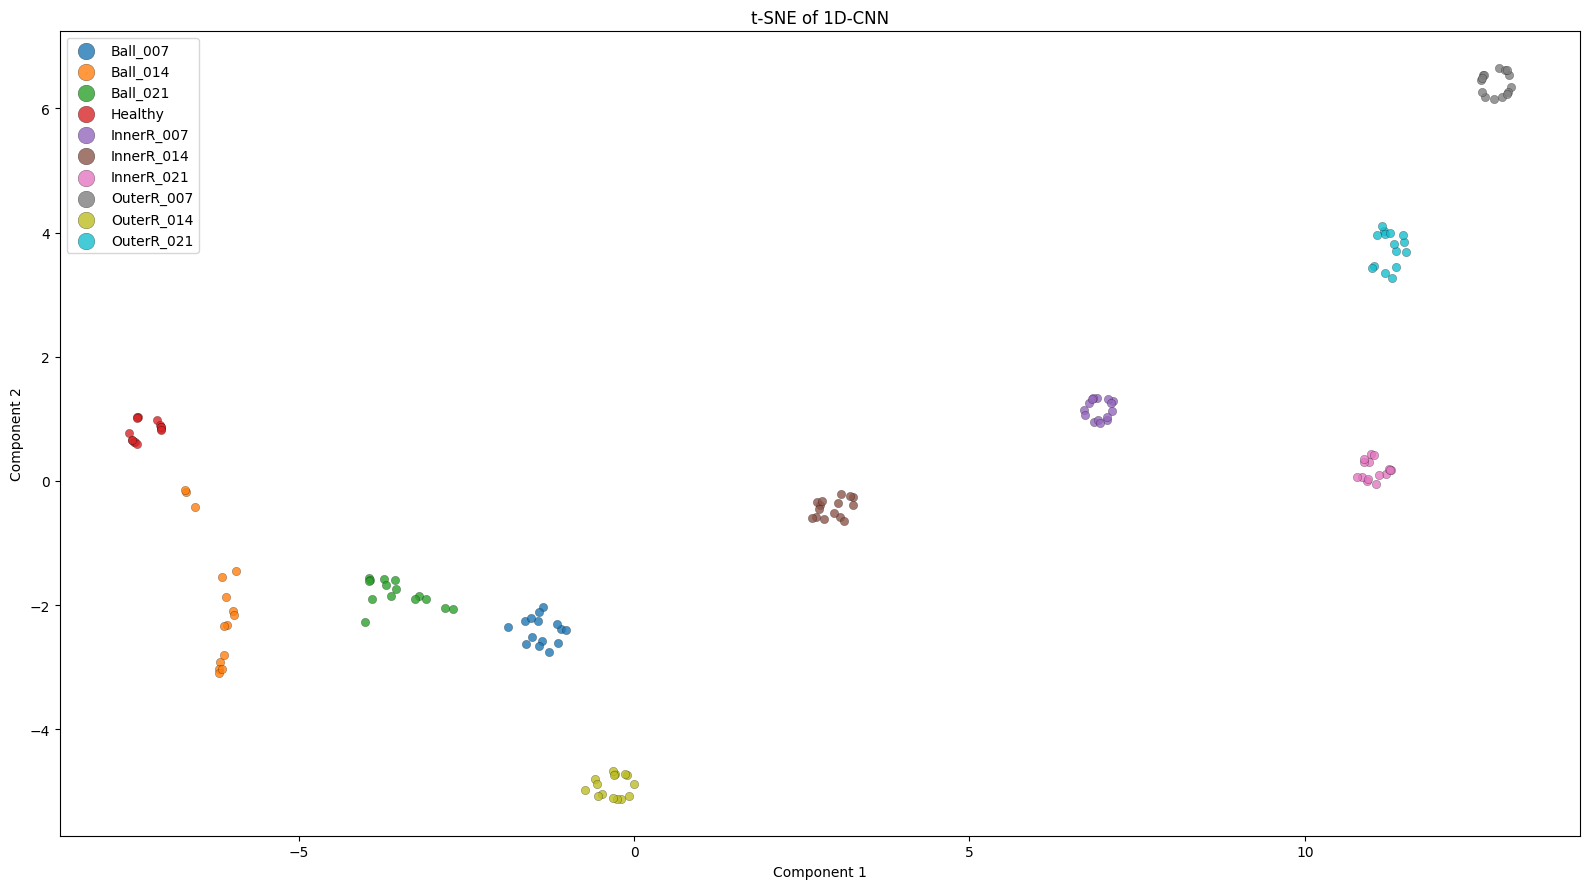

Classes: ['Ball_007', 'Ball_014', 'Ball_021', 'Healthy', 'InnerR_007', 'InnerR_014', 'InnerR_021', 'OuterR_007', 'OuterR_014', 'OuterR_021']
Shared usable length: 120000

Final dataset shapes:
Train: (150, 1, 5000) (150,)
Val:   (30, 1, 5000) (30,)
Test:  (180, 1, 5000) (180,)
Using device: cuda
Run 8
Total runtime: 131.8756 seconds
Early stopping triggered
Test Loss: 0.0604
Test Acc:  0.9889

Classification Report:
              precision    recall  f1-score   support

    Ball_007       0.95      1.00      0.97        18
    Ball_014       1.00      0.94      0.97        18
    Ball_021       0.94      0.94      0.94        18
     Healthy       1.00      1.00      1.00        18
  InnerR_007       1.00      1.00      1.00        18
  InnerR_014       1.00      1.00      1.00        18
  InnerR_021       1.00      1.00      1.00        18
  OuterR_007       1.00      1.00      1.00        18
  OuterR_014       1.00      1.00      1.00        18
  OuterR_021       1.00      1.00      

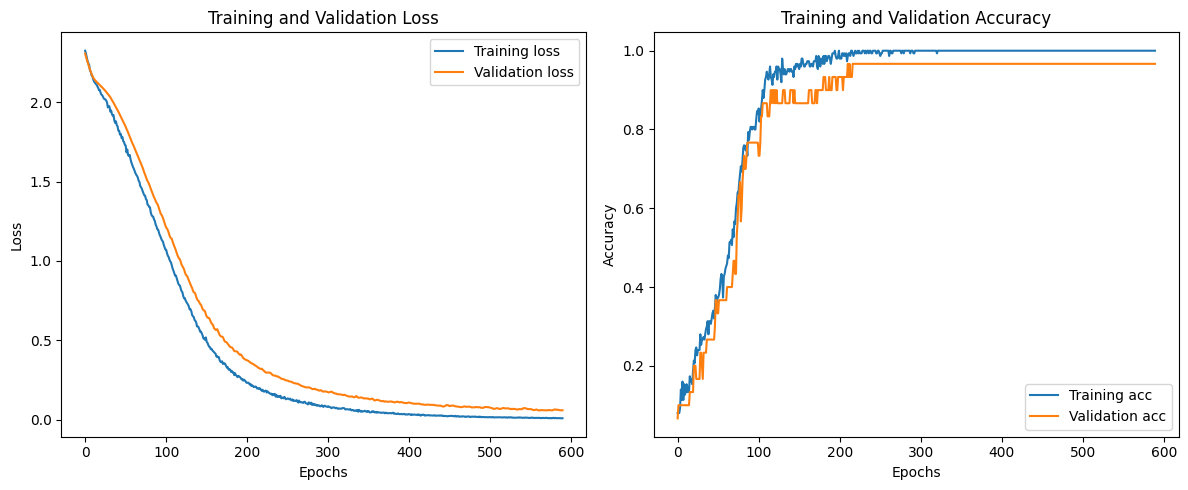

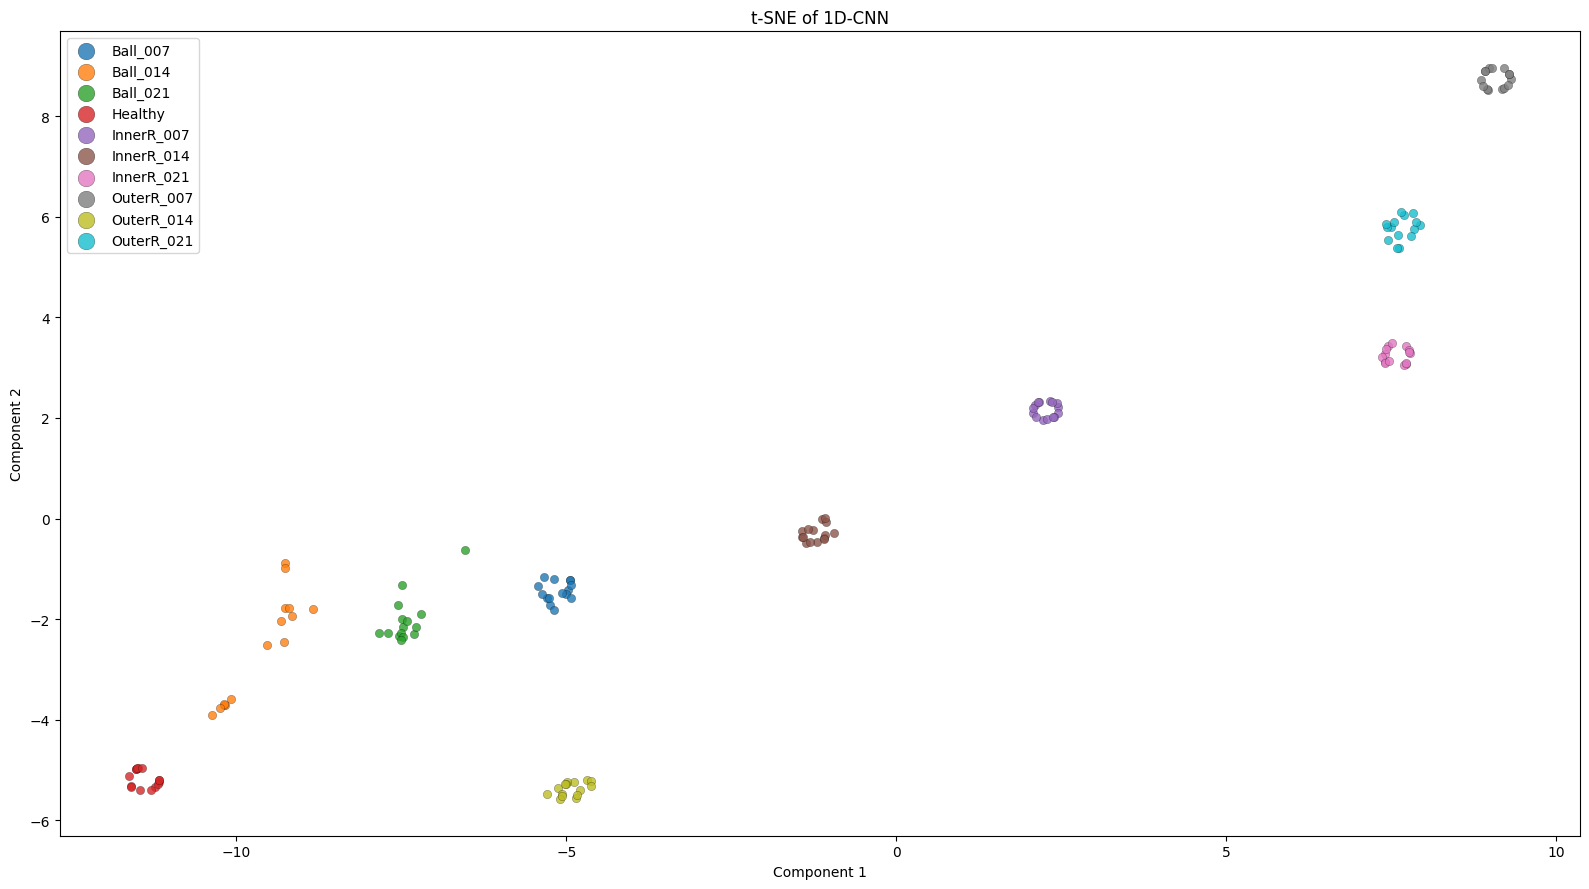

Classes: ['Ball_007', 'Ball_014', 'Ball_021', 'Healthy', 'InnerR_007', 'InnerR_014', 'InnerR_021', 'OuterR_007', 'OuterR_014', 'OuterR_021']
Shared usable length: 120000

Final dataset shapes:
Train: (150, 1, 5000) (150,)
Val:   (30, 1, 5000) (30,)
Test:  (180, 1, 5000) (180,)
Using device: cuda
Run 9
Total runtime: 149.2478 seconds
Early stopping triggered
Test Loss: 0.2137
Test Acc:  0.9333

Classification Report:
              precision    recall  f1-score   support

    Ball_007       0.90      1.00      0.95        18
    Ball_014       1.00      0.83      0.91        18
    Ball_021       0.84      0.89      0.86        18
     Healthy       1.00      1.00      1.00        18
  InnerR_007       1.00      1.00      1.00        18
  InnerR_014       0.72      1.00      0.84        18
  InnerR_021       1.00      1.00      1.00        18
  OuterR_007       1.00      1.00      1.00        18
  OuterR_014       1.00      1.00      1.00        18
  OuterR_021       1.00      0.61      

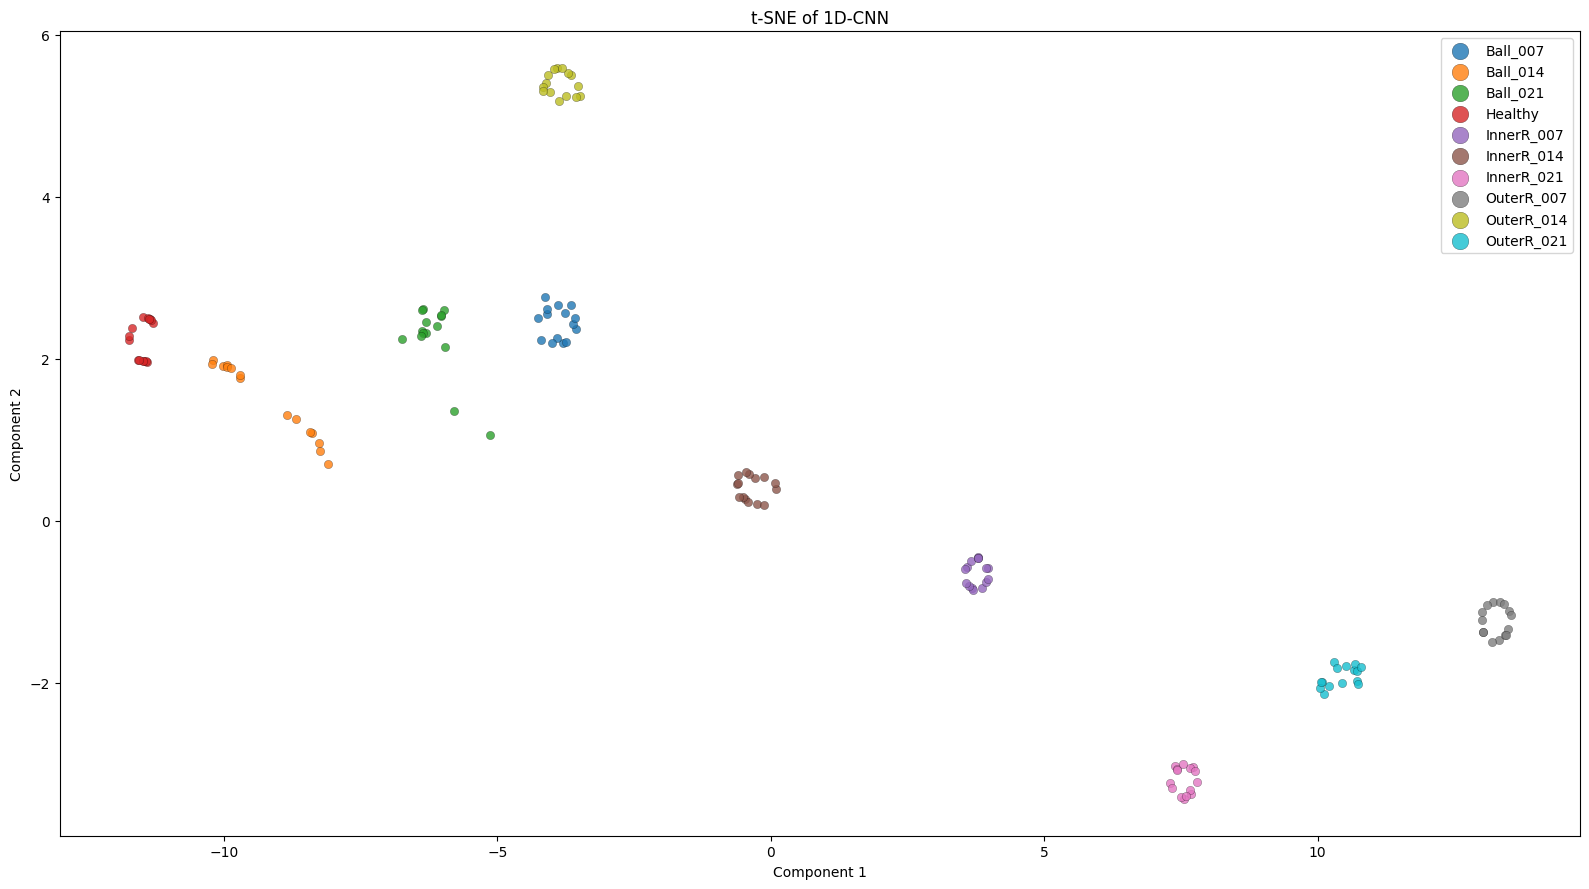

Classes: ['Ball_007', 'Ball_014', 'Ball_021', 'Healthy', 'InnerR_007', 'InnerR_014', 'InnerR_021', 'OuterR_007', 'OuterR_014', 'OuterR_021']
Shared usable length: 120000

Final dataset shapes:
Train: (150, 1, 5000) (150,)
Val:   (30, 1, 5000) (30,)
Test:  (180, 1, 5000) (180,)
Using device: cuda
Run 10
Total runtime: 159.7155 seconds
Early stopping triggered
Test Loss: 0.1505
Test Acc:  0.9333

Classification Report:
              precision    recall  f1-score   support

    Ball_007       0.90      1.00      0.95        18
    Ball_014       1.00      0.44      0.62        18
    Ball_021       0.67      0.89      0.76        18
     Healthy       0.95      1.00      0.97        18
  InnerR_007       1.00      1.00      1.00        18
  InnerR_014       1.00      1.00      1.00        18
  InnerR_021       0.95      1.00      0.97        18
  OuterR_007       1.00      1.00      1.00        18
  OuterR_014       1.00      1.00      1.00        18
  OuterR_021       1.00      1.00     

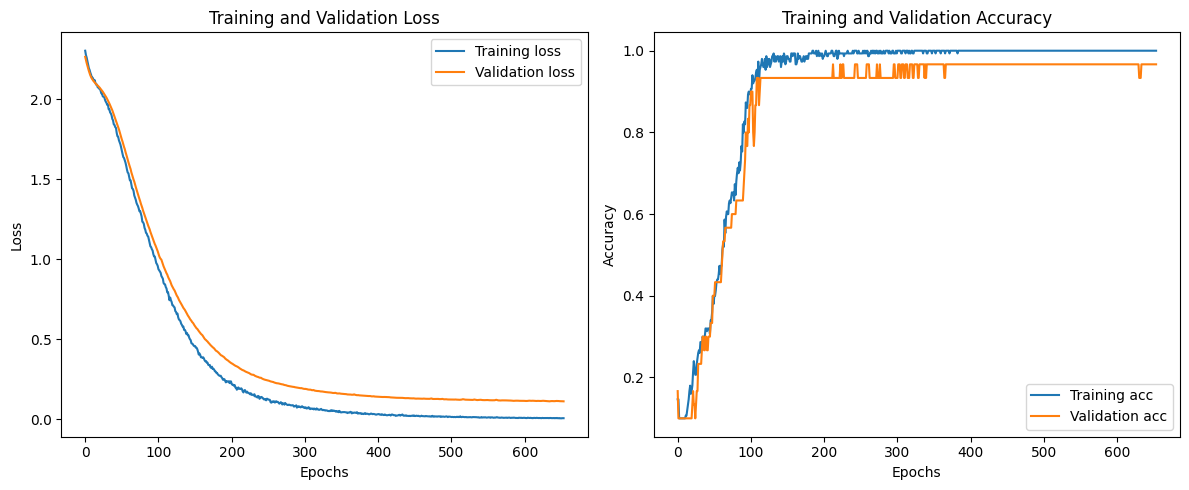

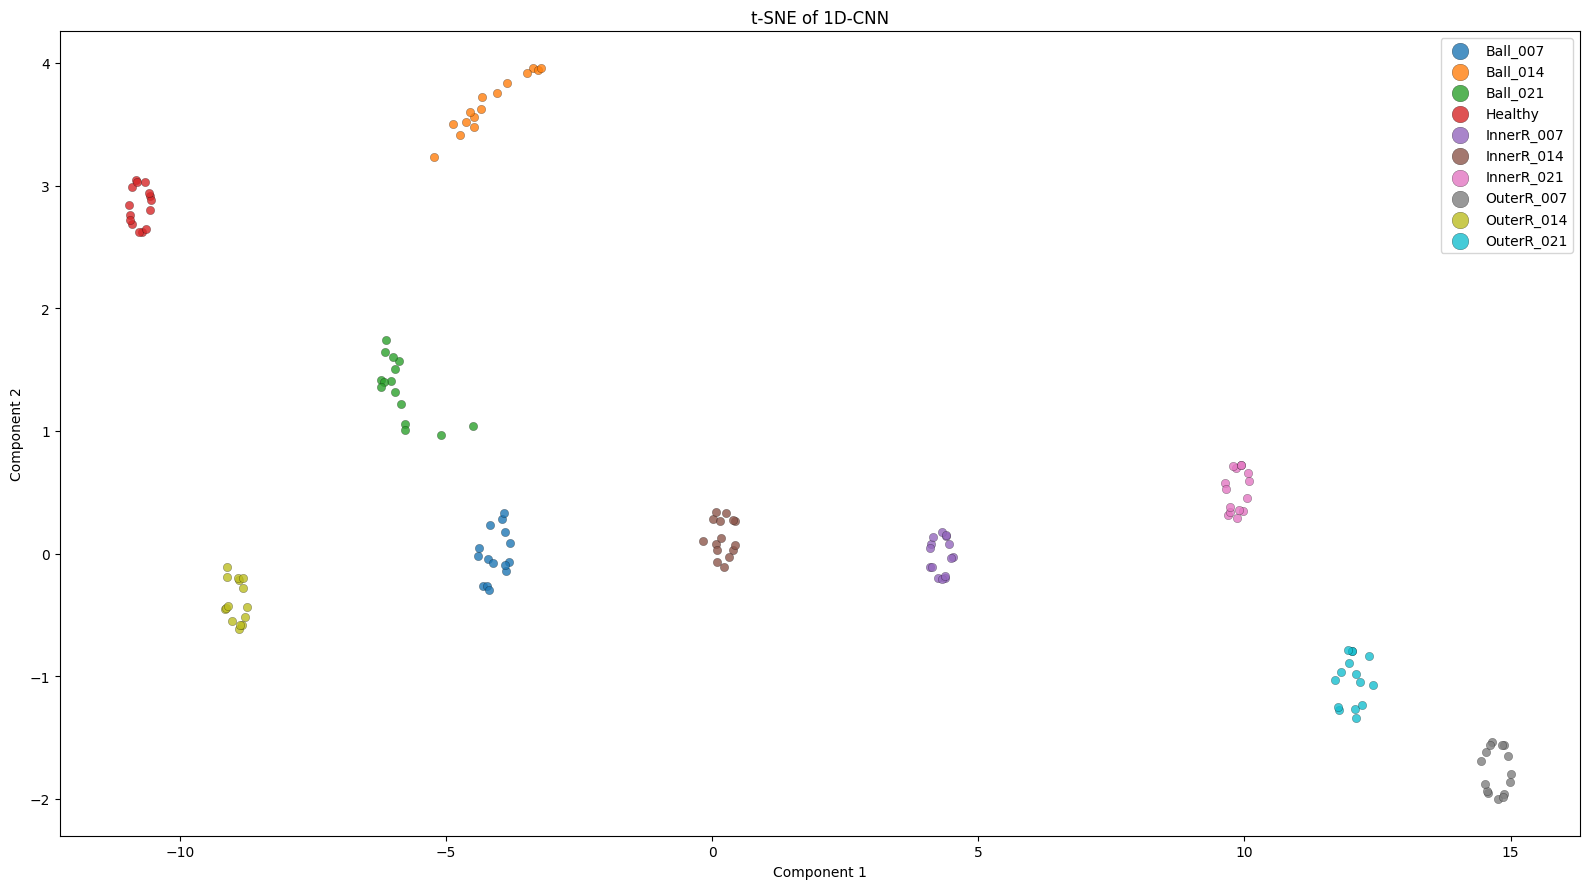

In [20]:
for runs in range(n_runs):

    # =========================================================
    # Configuration
    # =========================================================
    DATA_FOLDER = os.path.join('data', 'CWRU')
    
    WINDOW_SIZE = 5000
    STRIDE = 2500
    
    TRAIN_RATIO = 0.45
    VAL_RATIO = 0.10
    TEST_RATIO = 0.45
    
    # Must be >= WINDOW_SIZE to allow at least one window per block.
    # If BLOCK_SIZE > WINDOW_SIZE, overlapping windows stay inside each block,
    # so no raw samples are shared across datasets.
    BLOCK_SIZE = 10000
    
    # None -> different random split every run
    # int  -> reproducible random split
    RANDOM_SEED = None
    
    
    # =========================================================
    # Loading + preprocessing
    # =========================================================
    def preprocess_signal(x: np.ndarray) -> np.ndarray:
        x = x.astype(np.float32).squeeze()
        x = signal.detrend(x) * 9.81 * 1000
    
        b, a = signal.butter(8, 0.8, btype='lowpass')
        x = signal.filtfilt(b, a, x)
    
        return x.astype(np.float32)
    
    
    def load_first_de_signal(mat_path: str) -> np.ndarray | None:
        data = scio.loadmat(mat_path)
    
        de_keys = [k for k in data.keys() if "DE" in k and not k.startswith("__")]
        if not de_keys:
            print(f"Skipping {os.path.basename(mat_path)}: no DE signal found")
            return None
    
        return preprocess_signal(data[de_keys[0]])
    
    
    def load_class_signals(data_folder: str) -> dict[str, np.ndarray]:
        accdata_dict = {}
        class_names = []
        class_folders = sorted(
            f for f in os.listdir(data_folder)
            if os.path.isdir(os.path.join(data_folder, f))
        )
    
        for class_name in class_folders:
            class_path = os.path.join(data_folder, class_name)
            class_names.append(class_name)

    
            filelist = sorted(
                f for f in os.listdir(class_path)
                if f.lower().endswith(".mat")
            )
    
            class_signals = []
            for filename in filelist:
                filepath = os.path.join(class_path, filename)
                sig = load_first_de_signal(filepath)
                if sig is not None:
                    class_signals.append(sig)
    
            if class_signals:
                accdata_dict[class_name] = np.concatenate(class_signals).astype(np.float32)
    
        return accdata_dict,class_names
    
    
    # =========================================================
    # Signal helpers
    # =========================================================
    def center_crop_to_length(x: np.ndarray, target_len: int) -> np.ndarray:
        extra = len(x) - target_len
        start = extra // 2
        end = start + target_len
        return x[start:end]
    
    def make_windows(x: np.ndarray, window_size: int, stride: int) -> np.ndarray:
        if len(x) < window_size:
            return np.empty((0, 1, window_size), dtype=np.float32)
        
        starts = np.arange(0, len(x) - window_size + 1, stride)
        windows = np.stack([x[s:s + window_size] for s in starts], axis=0).astype(np.float32)
        
        return windows[:, np.newaxis, :]
    
    
    def split_into_blocks(x: np.ndarray, block_size: int) -> list[np.ndarray]:
        n_blocks = len(x) // block_size
        x = x[:n_blocks * block_size]
        return [x[i * block_size:(i + 1) * block_size] for i in range(n_blocks)]
    
    
    def windows_from_blocks(blocks: list[np.ndarray],
                            window_size: int,
                            stride: int) -> np.ndarray:
        all_windows = [make_windows(block, window_size, stride) for block in blocks]
        all_windows = [w for w in all_windows if len(w) > 0]
    
        if not all_windows:
            return np.empty((0, 1, window_size), dtype=np.float32)
    
        return np.concatenate(all_windows, axis=0)
    
    
    def split_counts(n_total: int,
                     train_ratio: float,
                     val_ratio: float,
                     test_ratio: float) -> tuple[int, int, int]:
        if not np.isclose(train_ratio + val_ratio + test_ratio, 1.0):
            raise ValueError("train_ratio + val_ratio + test_ratio must equal 1.0")
    
        n_train = int(n_total * train_ratio)
        n_val = int(n_total * val_ratio)
        n_test = n_total - n_train - n_val
        return n_train, n_val, n_test
    
    
    def shuffle_pair(X: np.ndarray, y: np.ndarray, rng: np.random.Generator):
        idx = rng.permutation(len(X))
        return X[idx], y[idx]
    
    
    # =========================================================
    # Leakage-safe balanced dataset builder
    # =========================================================
    def build_balanced_datasets(
        accdata_dict: dict[str, np.ndarray],
        block_size: int,
        window_size: int,
        stride: int,
        train_ratio: float,
        val_ratio: float,
        test_ratio: float,
        random_seed=None,
    ):
        """
        Safe pipeline:
        1. Equalize signal length across classes
        2. Split each class into disjoint blocks
        3. Randomly assign full blocks to train/val/test
        4. Make overlapping windows only inside those blocks
        5. Balance all classes to the same number of windows per split
        """
    
        if block_size < window_size:
            raise ValueError("block_size must be >= window_size to avoid empty blocks/windows")
    
        rng = np.random.default_rng(random_seed)
    
        class_names = sorted(accdata_dict.keys())
        class_to_label = {name: i for i, name in enumerate(class_names)}
    
        # shared usable signal length
        # print("Signal lengths:")
        # for name in class_names:
        #     print(f"  {name}: {len(accdata_dict[name])}")

        shared_len = min(len(accdata_dict[name]) for name in class_names)
        shared_len = (shared_len // block_size) * block_size
    
        if shared_len < block_size:
            raise ValueError("Not enough shared data for even one block per class")
    
        print("Classes:", class_names)
        print("Shared usable length:", shared_len)
    
        # Per-class split windows
        per_class_split_windows = {}
    
        for class_name in class_names:
            x = center_crop_to_length(accdata_dict[class_name], shared_len)
            blocks = split_into_blocks(x, block_size)
    
            n_blocks = len(blocks)
            n_train_b, n_val_b, n_test_b = split_counts(
                n_blocks, train_ratio, val_ratio, test_ratio
            )
    
            if n_train_b == 0 or n_val_b == 0 or n_test_b == 0:
                raise ValueError(
                    f"Class {class_name} has too few blocks ({n_blocks}) for the chosen split ratios."
                )
    
            # Random block assignment
            perm = rng.permutation(n_blocks)
            train_idx = perm[:n_train_b]
            val_idx = perm[n_train_b:n_train_b + n_val_b]
            test_idx = perm[n_train_b + n_val_b:]
    
            train_blocks = [blocks[i] for i in train_idx]
            val_blocks = [blocks[i] for i in val_idx]
            test_blocks = [blocks[i] for i in test_idx]
    
            X_train_c = windows_from_blocks(train_blocks, window_size, stride)
            X_val_c = windows_from_blocks(val_blocks, window_size, stride)
            X_test_c = windows_from_blocks(test_blocks, window_size, stride)
    
            per_class_split_windows[class_name] = {
                "train": X_train_c,
                "val": X_val_c,
                "test": X_test_c,
            }
    
            # print(
            #     f"{class_name}: "
            #     f"blocks={n_blocks}, "
            #     f"train_blocks={len(train_blocks)}, val_blocks={len(val_blocks)}, test_blocks={len(test_blocks)}, "
            #     f"train_windows={len(X_train_c)}, val_windows={len(X_val_c)}, test_windows={len(X_test_c)}"
            # )
    
        # Balance number of windows per class within each split
        n_train_per_class = min(len(per_class_split_windows[c]["train"]) for c in class_names)
        n_val_per_class = min(len(per_class_split_windows[c]["val"]) for c in class_names)
        n_test_per_class = min(len(per_class_split_windows[c]["test"]) for c in class_names)
    
        # print("\nBalanced windows per class:")
        # print("Train:", n_train_per_class)
        # print("Val:  ", n_val_per_class)
        # print("Test: ", n_test_per_class)
    
        X_train_list, y_train_list = [], []
        X_val_list, y_val_list = [], []
        X_test_list, y_test_list = [], []
    
        for class_name in class_names:
            label = class_to_label[class_name]
    
            Xc_train = per_class_split_windows[class_name]["train"]
            Xc_val = per_class_split_windows[class_name]["val"]
            Xc_test = per_class_split_windows[class_name]["test"]
    
            # Randomly pick same number of windows from each class
            train_sel = rng.permutation(len(Xc_train))[:n_train_per_class]
            val_sel = rng.permutation(len(Xc_val))[:n_val_per_class]
            test_sel = rng.permutation(len(Xc_test))[:n_test_per_class]
    
            Xc_train = Xc_train[train_sel]
            Xc_val = Xc_val[val_sel]
            Xc_test = Xc_test[test_sel]
    
            yc_train = np.full(len(Xc_train), label, dtype=np.int64)
            yc_val = np.full(len(Xc_val), label, dtype=np.int64)
            yc_test = np.full(len(Xc_test), label, dtype=np.int64)
    
            X_train_list.append(Xc_train)
            y_train_list.append(yc_train)
    
            X_val_list.append(Xc_val)
            y_val_list.append(yc_val)
    
            X_test_list.append(Xc_test)
            y_test_list.append(yc_test)
    
        X_train = np.concatenate(X_train_list, axis=0)
        y_train = np.concatenate(y_train_list, axis=0)
    
        X_val = np.concatenate(X_val_list, axis=0)
        y_val = np.concatenate(y_val_list, axis=0)
    
        X_test = np.concatenate(X_test_list, axis=0)
        y_test = np.concatenate(y_test_list, axis=0)
    
        # Normalize from train only
        train_mean = X_train.mean()
        train_std = X_train.std()
    
        X_train = (X_train - train_mean) / (train_std + 1e-8)
        X_val = (X_val - train_mean) / (train_std + 1e-8)
        X_test = (X_test - train_mean) / (train_std + 1e-8)
    
        # Final shuffle
        X_train, y_train = shuffle_pair(X_train, y_train, rng)
        X_val, y_val = shuffle_pair(X_val, y_val, rng)
        X_test, y_test = shuffle_pair(X_test, y_test, rng)
    
        return {
            "X_train": X_train,
            "y_train": y_train,
            "X_val": X_val,
            "y_val": y_val,
            "X_test": X_test,
            "y_test": y_test,
            "class_names": class_names,
            "class_to_label": class_to_label,
            "shared_len": shared_len,
            "train_mean": train_mean,
            "train_std": train_std,
        }
    
    
    # =========================================================
    # Main
    # =========================================================
    if __name__ == "__main__":
        accdata_dict,class_names = load_class_signals(DATA_FOLDER)
        classes = sorted(accdata_dict.keys())
        num_classes = len(class_names)
    
        # print("\nStored keys:")
        # print(accdata_dict.keys())
        # for key in accdata_dict:
        #     print(key, accdata_dict[key].shape)
        classes = sorted(accdata_dict.keys())
        datasets = build_balanced_datasets(
            accdata_dict=accdata_dict,
            block_size=BLOCK_SIZE,
            window_size=WINDOW_SIZE,
            stride=STRIDE,
            train_ratio=TRAIN_RATIO,
            val_ratio=VAL_RATIO,
            test_ratio=TEST_RATIO,
            random_seed=RANDOM_SEED,
        )

        X_train = datasets["X_train"]
        y_train = datasets["y_train"]
        X_val = datasets["X_val"]
        y_val = datasets["y_val"]
        X_test = datasets["X_test"]
        y_test = datasets["y_test"]
    
        print("\nFinal dataset shapes:")
        print("Train:", X_train.shape, y_train.shape)
        print("Val:  ", X_val.shape, y_val.shape)
        print("Test: ", X_test.shape, y_test.shape)
    
        # print("\nTrain classes:", np.unique(y_train))
        # print("Val classes:  ", np.unique(y_val))
        # print("Test classes: ", np.unique(y_test))
    
        # print("\nClass balance:")
        # for split_name, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
        #     counts = np.bincount(y, minlength=len(datasets["class_names"]))
        #     print(f"{split_name}: {counts}")
    
    if __name__ == "__main__": # CNN
    
        # -------------------------------------------------
        # Build dataset
        # -------------------------------------------------
        class BearingDataset(Dataset):
            def __init__(self, X, y):
                X = np.asarray(X, dtype=np.float32)
                y = np.asarray(y, dtype=np.int64)
                # If data is (N, L), add channel dimension -> (N, 1, L)
                if X.ndim == 2:
                    X = X[:, np.newaxis, :]
                self.X = torch.from_numpy(X)
                self.y = torch.from_numpy(y)
            def __len__(self):
                return len(self.y)
            def __getitem__(self, idx):
                return self.X[idx], self.y[idx]
    
        # -------------------------------------------------
        # Classification
        # -------------------------------------------------
    
    
        # -------------------------------------------------
        # Create datasets
        # -------------------------------------------------
    
        train_dataset = BearingDataset(X_train, y_train)
        val_dataset   = BearingDataset(X_val, y_val)
        test_dataset  = BearingDataset(X_test, y_test)
    
        # -------------------------------------------------
        # Create dataloaders
        # -------------------------------------------------
        batch_size = 32
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        class Bearing1DCNN(nn.Module):
            def __init__(self, num_classes=num_classes):
                super().__init__()
                # Kernel layers with batch norm, ReLU, and max pooling
                # Kernel sizes 100 and 50 chosen based on literature
                # maxpooling layers based on literature
                self.features = nn.Sequential(
                    nn.Conv1d(1, 64, kernel_size=100, stride=2, padding=50),
                    # nn.BatchNorm1d(64),
                    nn.ReLU(),
                    nn.MaxPool1d(4),

                    nn.Conv1d(64, 32, kernel_size=50, stride=1, padding=25),
                    # nn.BatchNorm1d(32),
                    nn.ReLU(),
                    nn.MaxPool1d(4),
                )
                
                self.classifier = nn.Sequential(
                    nn.Flatten(),
                    nn.Dropout(0.3),
                    nn.LazyLinear(100),
                    nn.ReLU(),
                    nn.Linear(100, num_classes)
                )

            def forward(self, x):
                x = self.features(x)
                x = self.classifier(x)
                return x
    
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print("Using device:", device)
        print(f"Run {runs+1}")
        t1 = time.perf_counter()
        print(f"Total runtime: {t1 - t0:.4f} seconds")
    
        model = Bearing1DCNN(num_classes=10).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
        # optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-5)
    
        def train_one_epoch(model, loader, criterion, optimizer, device):
            model.train()
    
            running_loss = 0.0
            correct = 0
            total = 0
    
            for X_batch, y_batch in loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
    
                optimizer.zero_grad()
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
    
                loss.backward()
                optimizer.step()
    
                running_loss += loss.item() * X_batch.size(0)
                preds = outputs.argmax(dim=1)
    
                correct += (preds == y_batch).sum().item()
                total += y_batch.size(0)
            epoch_loss = running_loss / total
            epoch_acc = correct / total
    
            return epoch_loss, epoch_acc
    
        @torch.no_grad()
        def extract_embeddings(model, loader, device):
            model.eval()
            embeddings = []
            labels = []

            for X_batch, y_batch in loader:
                X_batch = X_batch.to(device)

                x = model.features(X_batch)
                x = model.classifier[:-1](x)   # output before final Linear layer

                embeddings.append(x.cpu().numpy())
                labels.append(y_batch.numpy())

            embeddings = np.concatenate(embeddings, axis=0)
            labels = np.concatenate(labels, axis=0)

            return embeddings, labels
        @torch.no_grad()
        def evaluate(model, loader, criterion, device):
            model.eval()
            running_loss = 0.0
            correct = 0
            total = 0
    
            all_preds = []
            all_labels = []
    
            for X_batch, y_batch in loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
    
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                running_loss += loss.item() * X_batch.size(0)
    
                preds = outputs.argmax(dim=1)
                correct += (preds == y_batch).sum().item()
                total += y_batch.size(0)
    
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y_batch.cpu().numpy())
    
            epoch_loss = running_loss / total
            epoch_acc = correct / total
            return epoch_loss, epoch_acc, all_labels, all_preds
    
        epoc_hist = []
        train_loss_hist = []
        val_loss_hist = []
        train_acc_hist = []
        val_acc_hist = []
    
        num_epochs = 1000
        best_val_acc = 0.0
        best_val_loss = float('inf')
        patience = 20
        counter = 0
        best_model_state = None
    
        for epoch in range(num_epochs):
        
            train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
            val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
            epoc_hist.append(epoch)
    
            train_loss_hist.append(train_loss)
            val_loss_hist.append(val_loss)
            train_acc_hist.append(train_acc)
            val_acc_hist.append(val_acc)
    
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_val_acc = val_acc
                counter = 0
                best_model_state = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), os.path.join('outputs', 'models', 'best_bearing_1dcnn_k100_k50_CWRU_split.pt'))
            else:
                counter += 1
    
            if counter >= patience:
                print("Early stopping triggered")
                break



    if __name__ == "__main__": # Final evaluation and plotting
        # Restore best model
        if best_model_state is not None:
            model.load_state_dict(best_model_state)
    
        test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion, device)
        print(f"Test Loss: {test_loss:.4f}")
        print(f"Test Acc:  {test_acc:.4f}")
    
        print("\nClassification Report:")
        print(classification_report(y_true, y_pred, target_names=classes))
           # Confusion matrix (counts)
        cm = confusion_matrix(y_true, y_pred)
        cms.append(cm)
        # Row-wise percentages
        cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
        cms_percent.append(cm_percent)
        # Create annotation labels: percent + count
        annot_labels = np.empty_like(cm).astype(str)
        acc = (np.array(y_true) == np.array(y_pred)).mean()
        accs.append(acc)
        epochs.append(epoc_hist[-1])
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                annot_labels[i, j] = f"{cm_percent[i, j]:.1f}%\n({cm[i, j]})"
    
        # # Plot
        # plt.figure(figsize=(8, 6))
    
        # sns.heatmap(
        #     cm_percent,
        #     annot=annot_labels,
        #     fmt="",
        #     cmap="Blues",
        #     xticklabels=classes,
        #     yticklabels=classes,
        #     cbar_kws={"label": "Percentage (%)"}
        # )
    
        # plt.xlabel("Predicted Labels")
        # plt.ylabel("True Labels")
        # plt.title("Confusion Matrix (%) with Counts")
        # plt.tight_layout()
        # plt.savefig(os.path.join('outputs', 'figures', 'CM_CWRU_split.png'))
        # # plt.show()
    
        if epoc_hist[-1] < 1000 and epoc_hist[-1] > 400:
        
            fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 
        
            axes[0].plot(epoc_hist, train_loss_hist, label="Training loss")
            axes[0].plot(epoc_hist, val_loss_hist, label="Validation loss")
            axes[0].set_xlabel("Epochs")
            axes[0].set_ylabel("Loss")
            axes[0].set_title("Training and Validation Loss")
            axes[0].legend()
        
            axes[1].plot(epoc_hist, train_acc_hist, label="Training acc")
            axes[1].plot(epoc_hist, val_acc_hist, label="Validation acc")
            axes[1].set_xlabel("Epochs")
            axes[1].set_ylabel("Accuracy")
            axes[1].set_title("Training and Validation Accuracy")
            axes[1].legend()
        
            plt.tight_layout()
            plt.savefig(os.path.join('outputs', 'figures', 'ACC-LOSS_CWRU_split.png'))
            plt.show()
    def get_fault_family(name):
            if "Ball" in name:
                return "Ball"
            if "Outer" in name:
                return "Outer"
            if "Inner" in name:
                return "Inner"
            if name == "Healthy":
                return "Healthy"
            return "Other"
    family_to_classes = {}
    for idx, name in enumerate(class_names):
        fam = get_fault_family(name)
        family_to_classes.setdefault(fam, []).append(idx)
    embeddings, tsne_labels = extract_embeddings(model, train_loader, device)
    perplexity = min(30, len(embeddings) - 1)
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        random_state=RANDOM_SEED
    )
    embeddings_2d = tsne.fit_transform(embeddings)
    plt.figure(figsize=(16, 9))
    for class_idx, class_name in enumerate(class_names):
        idx = tsne_labels == class_idx
        plt.scatter(
            embeddings_2d[idx, 0],
            embeddings_2d[idx, 1],
            # color=class_colors[class_idx],
            label=class_name,
            edgecolors='k',
            linewidths=0.2,
            alpha=0.8
        )
    plt.title(f"t-SNE of 1D-CNN")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    
    plt.legend(loc="best", fontsize="medium", markerscale=2)
    plt.tight_layout()
    if epoc_hist[-1] < 1000 and epoc_hist[-1] > 100:
        plt.savefig(os.path.join('outputs', 'figures', 'TSNE_CWRU_split.png'))
        plt.show()



## 5. Averages and final confusion matrix

Run this cell after the complete run loop. It prints the original mean/std test accuracy and epoch summaries, then saves and displays the aggregate confusion matrix.
The original epoch summaries use zero-based epoch indices.

Generated files are written to `outputs/models/` and `outputs/figures/`. The original saving behavior is retained: runs reuse the same checkpoint and training-curve filenames.

Mean Accuracy: 0.9638888888888889
Std Accuracy : 0.02747052292239137
Average epochs : 626.5
Shortest epoch run : 275
Longest epoch run : 999
Total runtime: 178.7170 seconds with 10 runs


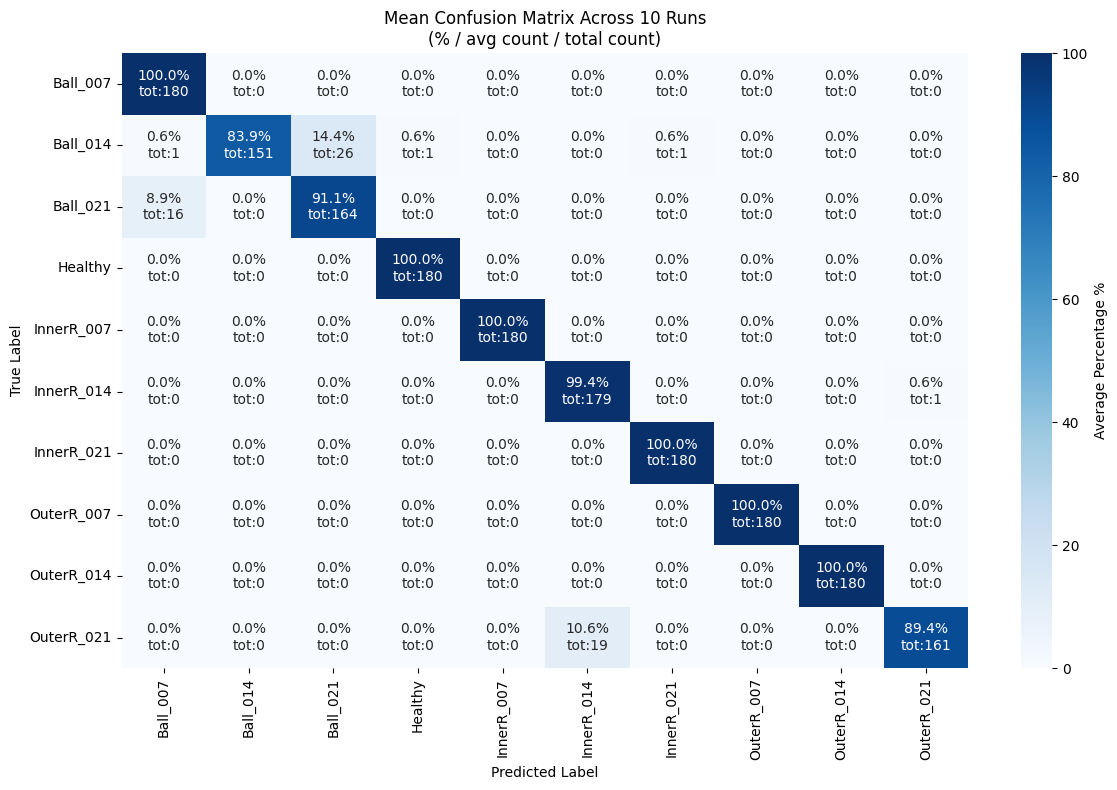

In [21]:
# -----------------------
# averages
# -----------------------
avg_cm = np.mean(cms, axis=0)
tot_cm = np.sum(cms, axis=0)   
avg_cm_pct = np.mean(cms_percent, axis=0)
avg_epochs = np.mean(epochs,axis=0)
print("Mean Accuracy:", np.mean(accs))
print("Std Accuracy :", np.std(accs))
print("Average epochs :", avg_epochs)
print(f"Shortest epoch run : {min(epochs)}")
print(f"Longest epoch run : {max(epochs)}")


annot = np.empty(avg_cm.shape, dtype=object)

for i in range(avg_cm.shape[0]):
    for j in range(avg_cm.shape[1]):
        annot[i, j] = (
            f"{avg_cm_pct[i,j]:.1f}%\n"
            # f"avg:{avg_cm[i,j]:.1f}\n"
            f"tot:{tot_cm[i,j]}"
        )
plt.figure(figsize=(12,8))

sns.heatmap(
    avg_cm_pct,
    annot=annot,
    fmt="",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    cbar_kws={"label":"Average Percentage %"}
)

plt.title(f"Mean Confusion Matrix Across {n_runs} Runs\n(% / avg count / total count)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(os.path.join('outputs', 'figures', f'CM_CWRU_split_{n_runs}_runs_nob.png'))
t1 = time.perf_counter()
print(f"Total runtime: {t1 - t0:.4f} seconds with {n_runs} runs")
plt.show()

---
**Data source:** [Case Western Reserve University Bearing Data Center](https://engineering.case.edu/bearingdatacenter).
The ten supplied `.mat` files are included without changing their contents or filenames.